# Regression Prep

The following notebook prepares our cleaned building data to be used for a regression analysis that predicts the number of units in a building based on a building's volume and potentially it's sqft. The original `building` geopackage comes from cleaning done in the ElectriGrid repository, and combines data sourced from Zillow and Microsoft Building Footprint.

**Steps:**
1. Find base area of each building, based on geometry (and save as column)
2. Multiply base area by building height, and save as `volume` variable
3. Separate observations with and without unit data
4. Evaluate `sqft_type` variable and its unique values. What does it mean, and can it help us in our regression?

In [9]:
import geopandas as gpd
import os
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# for checking distributions
import scipy.stats as stats
from scipy.stats import normaltest
from scipy.stats import kstest

In [10]:
# load building data 
building = gpd.read_parquet('~/../../capstone/electrigrid/data/final_building.parquet')

In [11]:
# load parcel data
parcels = gpd.read_parquet('~/../../capstone/electrigrid/data/parcels/parcels_final.parquet')

In [12]:
# remind ourselves of the data
building.head(3)

,source,id,height_m,var,region,parcel_ID,type,year,room,heat,...,p_ID,area,code,zillow_index,unit,area_m2,volume_m3,total_volume_m3,volume_share,geometry
18573,ms,UnitedStates_023010013_8142,4.508334,0.886133,USA,480115.0,Multi,2007.0,1.0,None,...,460,PGE/SCE,RI000,453152.0,1.0,62.973518,283.905634,853.757240,NaN,POINT (-121.54645 40.08099)
26238,osm,759299775,1.686291,0.644541,USA,10084995.0,Multi,NaN,1.0,None,...,302,PGE/SCE,RI101,6245297.0,2.0,38.333495,64.641441,12930.381426,NaN,POINT (-121.43021 40.67640)
30005,ms,UnitedStates_023010010_16,3.319534,0.280181,USA,10001573.0,Multi,NaN,3.0,None,...,357,PGE/SCE,RI101,6244425.0,1.0,283.595485,941.404872,7037.163187,NaN,POINT (-121.69719 40.87005)


## Finding Volume

In [13]:
# confirm what current crs is 
building.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [14]:
# reproject data frame to crs with meters as units
building_m = building.to_crs("EPSG:6933")

In [15]:
# find and create column from polygon area
building_m['area_m2'] = building_m.geometry.area

# rename height column to be clear about units
building_m.rename(columns={"height":"height_m"}, inplace = True)

building_m.head(2)

,source,id,height_m,var,region,parcel_ID,type,year,room,heat,...,p_ID,area,code,zillow_index,unit,area_m2,volume_m3,total_volume_m3,volume_share,geometry
18573,ms,UnitedStates_023010013_8142,4.508334,0.886133,USA,480115.0,Multi,2007.0,1.0,None,...,460,PGE/SCE,RI000,453152.0,1.0,0.0,283.905634,853.757240,NaN,POINT (-11727564.987 4715038.471)
26238,osm,759299775,1.686291,0.644541,USA,10084995.0,Multi,NaN,1.0,None,...,302,PGE/SCE,RI101,6245297.0,2.0,0.0,64.641441,12930.381426,NaN,POINT (-11716349.663 4773227.774)


In [16]:
# create volume column
building_m['volume_m3'] = building_m['area_m2'] * building_m['height_m']

building_m.head(2)

,source,id,height_m,var,region,parcel_ID,type,year,room,heat,...,p_ID,area,code,zillow_index,unit,area_m2,volume_m3,total_volume_m3,volume_share,geometry
18573,ms,UnitedStates_023010013_8142,4.508334,0.886133,USA,480115.0,Multi,2007.0,1.0,None,...,460,PGE/SCE,RI000,453152.0,1.0,0.0,0.0,853.757240,NaN,POINT (-11727564.987 4715038.471)
26238,osm,759299775,1.686291,0.644541,USA,10084995.0,Multi,NaN,1.0,None,...,302,PGE/SCE,RI101,6245297.0,2.0,0.0,0.0,12930.381426,NaN,POINT (-11716349.663 4773227.774)


## Separate Data

In [17]:
# explore number of rows that don't have unit data -- it's a lot
building_m['unit'].isna().sum()

555043

In [18]:
# keep only observations with unit data
building_w_units = building_m[~building_m['unit'].isna()]

# confirm operation worked
building_w_units['unit'].isna().sum()

0

### What is the distribution of unit type?

In [19]:
building_w_units['unit'].describe()

count    8.700735e+06
mean     1.885031e+00
std      1.337667e+01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.210000e+02
Name: unit, dtype: float64

In [20]:
# plot number units to see it's distribution -- will help us determine which stat model to use
# building_m_unit_data['unit'].plot(kind='bar')

<Axes: ylabel='Density'>

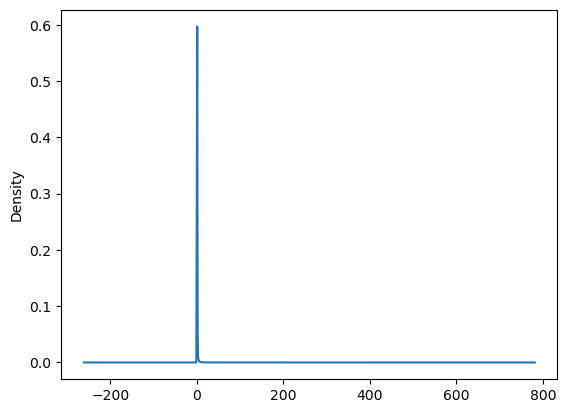

In [21]:
building_w_units['unit'].plot.density()

In [22]:
building_w_units.shape

(8700735, 27)

(0.0, 100.0)

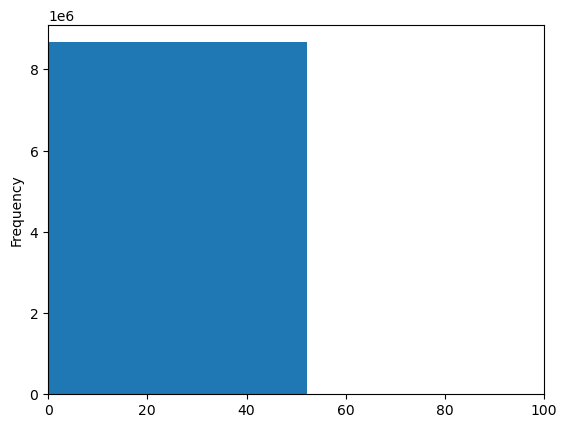

In [23]:
building_w_units['unit'].plot(kind = 'hist')
plt.xlim(0,100)

In [24]:
# is the unit data in the correct format?
building_w_units.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 8700735 entries, 18573 to 1188126
Data columns (total 27 columns):
 #   Column           Dtype   
---  ------           -----   
 0   source           object  
 1   id               object  
 2   height_m         float64 
 3   var              float64 
 4   region           object  
 5   parcel_ID        float64 
 6   type             object  
 7   year             float64 
 8   room             float64 
 9   heat             object  
 10  cool             object  
 11  own              object  
 12  value            float64 
 13  sqft_type        object  
 14  sqft             float64 
 15  ID               int32   
 16  GEOID            object  
 17  p_ID             object  
 18  area             object  
 19  code             object  
 20  zillow_index     float64 
 21  unit             float64 
 22  area_m2          float64 
 23  volume_m3        float64 
 24  total_volume_m3  float64 
 25  volume_share     float64 
 26  geometr

### Using Statistical Tests to Check Distribution

In [25]:
# Run normal test on the data
stat, p_val = normaltest(building_w_units['unit'])

# Check the p-value of the normaltest;
# if p-value is 0.05 or less, we have evidence to reject the null, that data has a NORMAL DISTRIBUTION
print('\nNormaltest p-value is: {:1.2f} \n'.format(p_val))


Normaltest p-value is: 0.00 



Data is most definitely not normally distributed.

Use Chi-square test to check if data has a Poisson distribution (takes ~ 10 minutes).

In [ ]:
from scipy.stats import chisquare
import numpy as np

# count how many times each integer appears in actual data
observed = np.bincount(building_w_units['unit'].astype(int))

# find mean, or lamda, of actual data
lambda_est = building_w_units.mean()

# save number of possible values
k_values = np.arange(len(observed))

# create poisson distribution 
expected = len(building_w_units) * poisson.pmf(k_values, lambda_est)

# Chi-square test (combine bins with expected < 5)
stat, p_val = chisquare(observed, expected)
print(f'Chi-square p-value: {p_val:.4f}')

### Multi-Unit Data Only

In [ ]:
# filtering out single unit homes to see if that helps
building_multi_unit = building_w_units[~building_w_units['type'] == 'Single']

In [ ]:
# attempt to plot again
building_multi_unit['unit'].plot.density()

## `sqft_type` and `sqft` investigation

In [ ]:
# view unique values 
building_m['sqft_type'].unique()

array(['living', None, 'others'], dtype=object)

In [ ]:
# # keep only living 
building_m_unit_data = building_w_units[building_w_units['sqft_type'] == 'living']

<Axes: xlabel='unit', ylabel='sqft'>

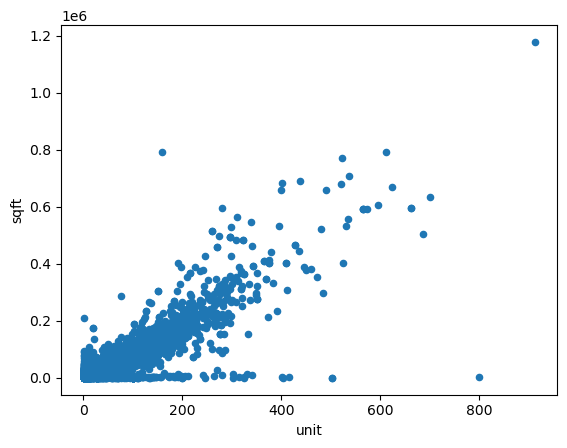

In [ ]:
# are sqft and unit correlated? --> will help answer what sqft actually represents (area per unit or per building)
building_m_unit_data.plot(kind='scatter',
              x='unit', 
              y='sqft')

The column `sqft` seems to represent **total** living area!

- separate single and multi homes, see if that makes a plotting difference?
- use tests to check distribution
- zillow data missing data?